# Character Identification CNN Model
Ze Hao version

### Import Modules

This notebook uses PyTorch for the processing.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.metrics as metrics
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import cv2
import os

from torchvision.transforms import v2

In [2]:
train_data_dir = "./chars_train_data"

### Object Classes
Set up the mapping of each character label to the label ID

In [3]:
char_classes = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "a": 10,
    "b": 11,
    "c": 12,
    "d": 13,
    "e": 14,
    "f": 15,
    "g": 16,
    "h": 17,
    "i": 18,
    "j": 19,
    "k": 20,
    "l": 21,
    "m": 22,
    "n": 23,
    "o": 24,
    "p": 25,
    "q": 26,
    "r": 27,
    "s": 28,
    "t": 29,
    "u": 30,
    "v": 31,
    "w": 32,
    "x": 33,
    "y": 34,
    "z": 35,
}
num_classes = len(char_classes)
print(num_classes)

36



### Setting up the dataset and dataloaders

For more information about creating custom dataset and using dataloader, check out [this tutorial](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).


In [43]:
class CharDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir="", is_train=True):
        self.data_dir = data_dir
        
        # Get all PNG files
        self.image_files = [f for f in os.listdir(data_dir) if f.lower().endswith('.png') or f.lower().endswith('.PNG')]
        if len(self.image_files) == 0:
            raise FileNotFoundError(f"No .png files found in {data_dir}")

        # Extract labels from filenames (everything before the first '_')
        self.labels = [f.split('_')[0] for f in self.image_files]
        
        self.is_train = is_train
        
    def __len__(self):
        return len(self.image_files) # Number of samples in dataset
        
    def __getitem__(self, index): # Defines what happens when a new sample is gotten from dataset
        fname = self.image_files[index]
        label_str = self.labels[index]
        label_idx = char_classes[label_str]

        img_path = os.path.join(self.data_dir, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(f"Cannot read image {img_path}")

        # Preprocess img with cv2 resize if incorrect size
        if img.shape[0] != 42 or img.shape[1] != 42:
            img = cv2.resize(img, (42, 42), interpolation=cv2.INTER_LINEAR)

        # Normalize to [0,1] and convert to float32
        img = img.astype('float32') / 255.0
        # Add channel dimension (1, 42, 42)
        img = np.expand_dims(img, axis=0)
        # Convert to torch tensors
        img_tensor = torch.tensor(img, dtype=torch.float32)

        return fname, img_tensor, label_idx


In [44]:
train_dataset = CharDataset(data_dir=train_data_dir, is_train=True)
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=50, shuffle=True)

test_dataset = CharDataset(data_dir=train_data_dir, is_train=False)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=50, shuffle=False)

### Inspect and visualize your data

It is recommended to inspect some samples of your data through visualization

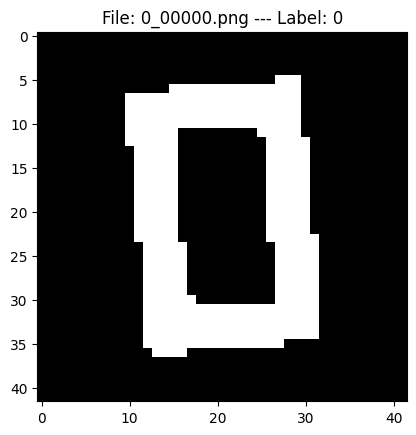

In [45]:
img_id, X_transformed, y = train_dataset[0]

plt.imshow(X_transformed[0], cmap='gray')
plt.title(f'File: {img_id} --- Label: {y}')
plt.show()


### Setting up the GPU

Kaggle provides GPU to speed up neural network evaluations. To activate it, click on Accelerator and select GPU. Note that there is a usage quota, so use it wisely.


In [46]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cpu



# Setting up your neural network model

As mentioned in the Getting Started section, you should check out this tutorial. Although not covered in lectures, you should consider learning and using these:

- Convolutional neural network layers ([``torch.nn.Conv2D``](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html))
- Maxpool layers ([``torch.nn.MaxPool2d``](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html))
- Adam optimizer ([``torch.nn.Adam``](https://pytorch.org/docs/stable/generated/torch.optim.Adam.html))
- [Pre-trained models](https://pytorch.org/vision/stable/models.html)
- [Loss functions](https://pytorch.org/docs/stable/nn.html#loss-functions)



In [49]:
import torch.nn as nn
import torch.nn.functional as F

# Add your Neural Network here (if using NN)

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 16, 3)
        
        self.fc1 = nn.Linear(16 * 9 * 9, 32)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) # Conv layer -> Relu -> Maxpool
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

net = Model()
net.to(device)

def count_params(net, trainable=False):
    if trainable:
        count = sum(p.numel() for p in net.parameters() if p.requires_grad)
    else:
        count = sum(p.numel() for p in net.parameters())
    return count

print(F'Network has {count_params(net, trainable=False)} parameters in total')
print(F'Network has {count_params(net, trainable=True)} trainable parameters in total')

Network has 45172 parameters in total
Network has 45172 trainable parameters in total


# Training the Model

Epoch 1/10: 100%|████████████████████████████████████████████████████████████████████| 886/886 [00:14<00:00, 59.93it/s]


Epoch [1/10] - Loss: 2.0108


Epoch 2/10: 100%|████████████████████████████████████████████████████████████████████| 886/886 [00:14<00:00, 59.19it/s]


Epoch [2/10] - Loss: 1.1656


Epoch 3/10: 100%|████████████████████████████████████████████████████████████████████| 886/886 [00:15<00:00, 58.88it/s]


...

Epoch [8/10] - Loss: 0.7563


Epoch 9/10: 100%|████████████████████████████████████████████████████████████████████| 886/886 [00:15<00:00, 57.94it/s]


Epoch [9/10] - Loss: 0.7286


Epoch 10/10: 100%|███████████████████████████████████████████████████████████████████| 886/886 [00:15<00:00, 57.64it/s]


Epoch [10/10] - Loss: 0.7090


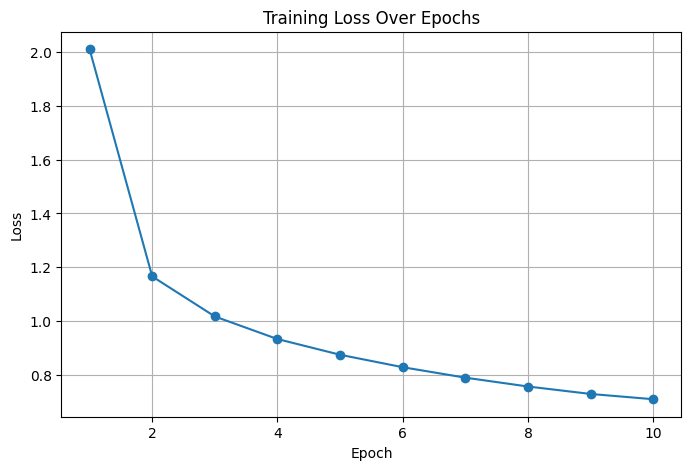

In [50]:
from tqdm import tqdm # for a progress bar

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters())
num_epochs = 10

epoch_losses = []  # store loss for each epoch

for epoch in range(num_epochs):
    net.train()  # set model to training mode
    running_loss = 0.0 
    # Running loss sums the loss values for each mini-batch, to later compute the average loss per epoch

    for img_id, X_transformed, y in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        X_transformed, y = X_transformed.to(device), y.to(device)

        # Forward pass
        y_pred_logits = net(X_transformed)
        loss = criterion(y_pred_logits, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_dataloader)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}")
    epoch_losses.append(avg_loss)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), epoch_losses, marker='o')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Making predictions
Naive: Simply take the highest logit and take it as prediction.

In [51]:
def predict(y_pred_logits): 
    # Take the index of the highest logit for each sample
    y_pred = torch.argmax(y_pred_logits, dim=1) # Note: returns a tensor
    return y_pred

### Evaluate on Train set

In [52]:
net.eval()  # set model to evaluation mode (disables dropout/batchnorm)
correct = 0
total = 0


with torch.no_grad():
    for img_id, X_transformed, y in tqdm(train_dataloader):
        X_transformed = X_transformed.to(device)
        y = y.to(device)

        # Forward pass
        outputs = net(X_transformed)
        
        # Predicted class = index of max logit
        predicted = predict(outputs)

        # Count correct predictions
        total += y.size(0)
        correct += (predicted == y).sum().item()

train_accuracy = 100 * correct / total
print(f'Total: {total}')
print(f'Correct: {correct}')
print(f'Accuracy on Train Data: {train_accuracy:.2f}%')


100%|███████████████████████████████████████████████████████████████████████████████| 886/886 [00:08<00:00, 102.78it/s]

Total: 44299
Correct: 35151
Accuracy on Train Data: 79.35%


### Inference on single sample

In [71]:
def predict_single_image(net, img_path, char_classes, show=True):
    # Load img
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")

    # Preprocess img with cv2 resize if incorrect size
    if img.shape[0] != 42 or img.shape[1] != 42:
        img = cv2.resize(img, (42, 42), interpolation=cv2.INTER_LINEAR)

    # Normalize and convert to tensor
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)   # (1, 42, 42)
    img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).to(device)  # (1, 1, 42, 42)

    net.eval()
    with torch.no_grad():
        output = net(img_tensor)
        predicted_class = predict(output).item()

    # Map index back to character
    inv_char_classes = {v: k for k, v in char_classes.items()}
    predicted_label = inv_char_classes[predicted_class]
    
    if show:
        # Show original image
        plt.imshow(img[0], cmap='gray')
        plt.title(f"File: {img_path} --- Predicted: {predicted_label}")
        
    return predicted_label

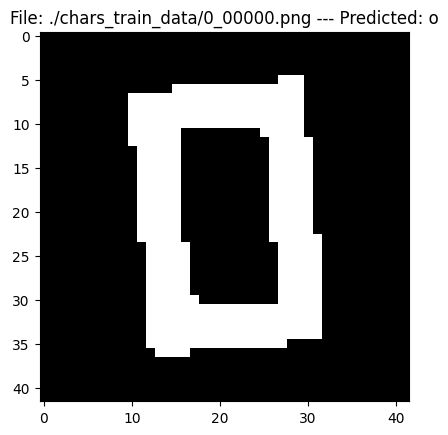

In [73]:
img_path = "./chars_train_data/0_00000.png"
pred = predict_single_image(net, img_path, char_classes, show=True)